# Contrastive pretext task

Self supervised pretraining of the food classifier encoder using a SimCLR style contrastive task. Two randomly augmented views of the same image are pushed close together in feature space, while views coming from different images are pushed apart, all without ever using the class labels. Once pretraining is done the encoder is frozen and used as a feature extractor, exactly as in the colorization notebook, and a traditional classifier is trained on top of the extracted features.

## Installing extra packages

In [ ]:
!pip install -q lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import os
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import torch.nn as nn
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import zipfile

## Downloading and extracting the dataset

Same as the other experiment notebooks. Colab local disk is wiped every session so this has to run again each time. Kaggle credentials are read from Colab secrets instead of being written in the notebook.

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

100% 2.84G/2.84G [02:19<00:00, 21.9MB/s]



In [ ]:
extract_path = "/content/ifood/"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/ifood_raw/ifood-2019-fgvc6.zip", "r") as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 2993532
drwxr-xr-x 2 root root       4096 Aug 16 09:49 .
drwxr-xr-x 1 root root       4096 Aug 16 09:49 ..
-rw-r--r-- 1 root root       3717 Aug 16 09:49 class_list.txt
-rw-r--r-- 1 root root     567555 Aug 16 09:49 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug 16 09:49 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug 16 09:49 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug 16 09:49 train_labels.csv
-rw-r--r-- 1 root root 2277605678 Aug 16 09:49 train_set.zip
-rw-r--r-- 1 root root     222409 Aug 16 09:49 val_labels.csv
-rw-r--r-- 1 root root  232027129 Aug 16 09:49 val_set.zip


In [ ]:
for zip_name in ["train_set.zip", "val_set.zip"]:
    print("Extracting", zip_name)
    with zipfile.ZipFile(f"/content/ifood/{zip_name}", "r") as zf:
        zf.extractall("/content/ifood/")

!ls -la /content/ifood/

Extracting train_set.zip
Extracting val_set.zip
total 2998096
drwxr-xr-x 4 root root       4096 Aug 16 09:49 .
drwxr-xr-x 1 root root       4096 Aug 16 09:49 ..
-rw-r--r-- 1 root root       3717 Aug 16 09:49 class_list.txt
-rw-r--r-- 1 root root     567555 Aug 16 09:49 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug 16 09:49 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug 16 09:49 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug 16 09:49 train_labels.csv
drwxr-xr-x 2 root root    4222976 Aug 16 09:49 train_set
-rw-r--r-- 1 root root 2277605678 Aug 16 09:49 train_set.zip
-rw-r--r-- 1 root root     222409 Aug 16 09:49 val_labels.csv
drwxr-xr-x 2 root root     446464 Aug 16 09:50 val_set
-rw-r--r-- 1 root root  232027129 Aug 16 09:49 val_set.zip


## Loading the shared utilities

FoodDataModule for the train and validation split, get_transforms and FoodDataset to build the feature extraction loaders later, count_parameters, evaluate, extract_features, run_linear_probe, run_knn_probe, load_class_names and save_metrics, all coming from food_utils.ipynb unchanged. Nothing new had to be added there for this notebook.

In [ ]:
drive.mount("/content/drive")

# path Angy
#PROJECT_DIR = "/content/drive/MyDrive/food-project"
# path K
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/food-project"

UTILS_PATH = os.path.join(PROJECT_DIR, "food_utils.ipynb")

%run "{UTILS_PATH}"

Mounted at /content/drive


## Experiment configuration

Same img_size, batch_size and cap as the medium net and colorization runs, so all three experiments see the same images. Temperature controls how sharply the contrastive loss separates positive pairs from negative ones.

In [ ]:
CFG = {
    "data_dir": "/content/ifood",
    "img_size": 224,
    "batch_size": 64,
    "max_epochs": 100,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "temperature": 0.5,
    "val_frac": 0.15,
    "cap": 500,
    "num_workers": 2,
    "num_classes": 251,
}

for key, value in CFG.items():
    print(key, ":", value)

data_dir : /content/ifood
img_size : 224
batch_size : 64
max_epochs : 100
lr : 0.001
weight_decay : 0.0001
temperature : 0.5
val_frac : 0.15
cap : 500
num_workers : 2
num_classes : 251


## Setting up the data module

Same FoodDataModule, same cap and same stratified split as every other experiment. During pretraining only the path column of train_df and val_df is used, the label column is ignored completely.

In [ ]:
dm = FoodDataModule(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    val_frac=CFG["val_frac"],
    cap=CFG["cap"],
    num_workers=CFG["num_workers"],
)
dm.setup()

train images: 96326
val images: 16999
test images: 11994


## Building two views of the same image

The contrastive task needs two independently augmented versions of each image, called a positive pair. The augmentation here is intentionally much stronger than the one used for the supervised training pipeline, random resized crop, horizontal flip, color jitter and occasional grayscale conversion.

The pretext task itself needs the two views to look meaningfully different, otherwise the encoder never has to learn anything beyond copying pixels, it can trivially tell the two views apart. Strong augmentation forces the encoder to learn features that stay stable despite changes in framing, lighting and color balance, which is exactly the kind of invariance useful for recognizing the same dish photographed under different conditions.

In [ ]:
def get_contrastive_transform(img_size=224):
    return T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.3, 1.0)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        T.RandomGrayscale(p=0.2),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

## Dataset for the pretext task

Only the image path is used, the label column is never read. Each call to getitem opens the image once and applies the augmentation pipeline twice, independently, giving two different views of the same picture.

In [ ]:
class ContrastiveFoodDataset(Dataset):
    def __init__(self, df, img_size=224):
        self.df = df.reset_index(drop=True)
        self.transform = get_contrastive_transform(img_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except (OSError, IOError):
            return self.__getitem__((idx + 1) % len(self.df))

        view1 = self.transform(img)
        view2 = self.transform(img)
        return view1, view2

## Building the dataloaders

In [ ]:
train_ds = ContrastiveFoodDataset(dm.train_df, img_size=CFG["img_size"])
val_ds = ContrastiveFoodDataset(dm.val_df, img_size=CFG["img_size"])

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"], drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], drop_last=True)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 1505
val batches: 265


drop_last is set to True here, the contrastive loss below builds a similarity matrix out of the whole batch, a last batch smaller than the others would need to be handled as a special case for no real benefit, simplest to just drop it.

## Preprocessing check

Checking shapes first, then looking at a couple of positive pairs to make sure the augmentation is doing something reasonable, not too mild and not so aggressive that the two views no longer look like the same dish at all.

In [ ]:
view1_batch, view2_batch = next(iter(train_loader))
print("view1 shape:", view1_batch.shape)
print("view2 shape:", view2_batch.shape)

view1 shape: torch.Size([64, 3, 224, 224])
view2 shape: torch.Size([64, 3, 224, 224])


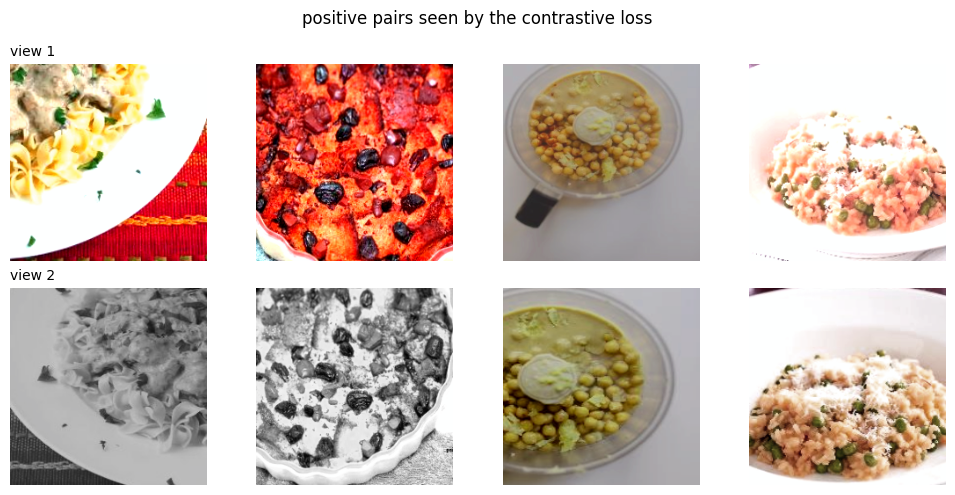

In [ ]:
def show_positive_pairs(dataset, n=4):
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 5))
    for i in range(n):
        v1, v2 = dataset[i]
        img1 = v1.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img2 = v2.permute(1, 2, 0).numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        axes[0, i].imshow(np.clip(img1, 0, 1))
        axes[0, i].axis("off")
        axes[1, i].imshow(np.clip(img2, 0, 1))
        axes[1, i].axis("off")
    axes[0, 0].set_title("view 1", loc="left", fontsize=10)
    axes[1, 0].set_title("view 2", loc="left", fontsize=10)
    plt.suptitle("positive pairs seen by the contrastive loss")
    plt.tight_layout()
    plt.show()


show_positive_pairs(train_ds, n=4)

## Encoder

Same residual block and same four stage structure as the medium net supervised encoder and the colorization encoder, same channel widths, 64 to 512. Unlike the colorization encoder, this one takes three channel RGB input, so it is architecturally identical to the supervised encoder down to the very first convolution, not just from stage one onward.

The encoder returns the spatial feature map after stage 4, 512 by 7 by 7, the same shape produced in the colorization notebook.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        if in_ch != out_ch:
            self.projection = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.projection = nn.Identity()

    def forward(self, x):
        identity = self.projection(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class MediumEncoder(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.stage1 = nn.Sequential(ResidualBlock(64, 64), nn.MaxPool2d(2))
        self.stage2 = nn.Sequential(ResidualBlock(64, 128), nn.MaxPool2d(2))
        self.stage3 = nn.Sequential(ResidualBlock(128, 256), nn.MaxPool2d(2))
        self.stage4 = nn.Sequential(ResidualBlock(256, 512), nn.MaxPool2d(2))

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x

## Projection head

A small two layer network sitting on top of the pooled encoder output, mapping the 512 dimensional feature vector down to a 128 dimensional space where the contrastive loss is actually computed.

The projection head is only used during pretraining and gets discarded afterward, exactly like the decoder in the colorization notebook. The features handed to the classifier later come from before the projection head, straight from the pooled encoder output.

In [ ]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class ContrastiveNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MediumEncoder(in_channels=3)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.projector = ProjectionHead(in_dim=512, hidden_dim=512, out_dim=128)

    def forward(self, x):
        features = self.encoder(x)
        pooled = self.gap(features).flatten(1)
        projected = self.projector(pooled)
        return projected

## Building the model and checking the parameter budget

Same reasoning as in the colorization notebook, the 10M limit applies to the encoder, since that is the only part reused after pretraining. The projection head is small and gets thrown away, so it does not count against the budget.

In [ ]:
model = ContrastiveNet()

encoder_params = sum(p.numel() for p in model.encoder.parameters())
projector_params = sum(p.numel() for p in model.projector.parameters())
print("encoder parameters:", f"{encoder_params:,}", f"({encoder_params / 1e6:.2f}M)")
print("projector parameters:", f"{projector_params:,}", f"({projector_params / 1e6:.2f}M)")

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG["img_size"], CFG["img_size"])
    out = model(dummy)
    print("output shape:", out.shape)   # expected [2, 128]

encoder parameters: 4,898,112 (4.90M)
projector parameters: 328,320 (0.33M)
output shape: torch.Size([2, 128])


## The contrastive loss

Known as NT-Xent, normalized temperature scaled cross entropy. For a batch of N images the two views produce 2N projected vectors. Each vector has exactly one positive, its own other view, and 2N minus 2 negatives, every other vector in the batch, views of different images.

Every vector is first normalized to unit length, so the dot product between any two vectors becomes their cosine similarity. All pairwise similarities are collected into a 2N by 2N matrix, divided by the temperature, and the diagonal, each vector compared with itself, is masked out since that comparison carries no information. For each row the task becomes a classification problem over the 2N minus 1 remaining columns, pick out the one positive among all the negatives, solved with ordinary cross entropy. Averaging over rows gives the final loss for the batch.

A lower temperature makes the loss more sensitive to small differences in similarity, pushing positives and negatives further apart, at the cost of a harder optimization landscape.

In [ ]:
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)

    z1 = nn.functional.normalize(z1, dim=1)
    z2 = nn.functional.normalize(z2, dim=1)

    representations = torch.cat([z1, z2], dim=0)
    similarity_matrix = torch.matmul(representations, representations.T) / temperature

    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z1.device)
    similarity_matrix = similarity_matrix.masked_fill(mask, float("-inf"))

    positive_idx = torch.arange(batch_size, device=z1.device)
    labels = torch.cat([positive_idx + batch_size, positive_idx], dim=0)

    loss = nn.functional.cross_entropy(similarity_matrix, labels)
    return loss

## Lightning module for the pretext task

No labels anywhere in this loop, only the two augmented views. train_loss and val_loss are the only things tracked, there is no notion of accuracy for a contrastive task the way there is for classification.

In [ ]:
class ContrastiveTask(L.LightningModule):
    def __init__(self, model, lr=1e-3, weight_decay=1e-4, temperature=0.5, max_epochs=100):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch, stage):
        view1, view2 = batch
        z1 = self(view1)
        z2 = self(view2)
        loss = nt_xent_loss(z1, z2, temperature=self.hparams.temperature)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs, eta_min=1e-6
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"},
        }

In [ ]:
lit_model = ContrastiveTask(
    model=model,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
    temperature=CFG["temperature"],
    max_epochs=CFG["max_epochs"],
)

## Callbacks and trainer setup

Checkpoint and early stopping watch val_loss, mode min, same as the
colorization notebook. Logged to its own ssl_contrastive folder on Drive.

In [ ]:
LOG_DIR = f"{PROJECT_DIR}/logs/ssl_contrastive"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"{LOG_DIR}/checkpoints",
    filename="epoch={epoch:02d}-val_loss={val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.005,
    mode="min",
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

logger = CSVLogger(save_dir=LOG_DIR, name="", version="")

trainer = L.Trainer(
    max_epochs=CFG["max_epochs"],
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    logger=logger,
    accelerator="auto",
    log_every_n_steps=20,
)

print("device:", trainer.strategy.root_device)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


device: cuda:0


## Training the pretext task

No labels involved anywhere in this call, only the two augmented views of each image.

In [ ]:
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Epoch 19/99 ━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 638/1505 0:08:10 • 0:11:05 1.30it/s train_loss_step: 3.107 val_loss:  
                                                                                 3.122 train_loss_epoch: 3.088     

## Loading the best checkpoint

In [ ]:
if checkpoint_cb.best_model_path:
  best_ckpt = checkpoint_cb.best_model_path
else:
  ckpt_path = os.path.join(PROJECT_DIR, "logs/ssl_contrastive/checkpoints")
  best_ckpt = os.path.join(ckpt_path, os.listdir(ckpt_path)[1])
print("best checkpoint:", best_ckpt)

eval_model = ContrastiveNet()
best_lit_model = ContrastiveTask.load_from_checkpoint(best_ckpt, model=eval_model)
best_lit_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

best checkpoint: /content/drive/MyDrive/Colab Notebooks/food-project/logs/ssl_contrastive/checkpoints/epoch=epoch=18-val_loss=val_loss=3.1224.ckpt


## Extracting features with the frozen encoder

The projection head is dropped here. Since this encoder expects ordinary three channel RGB input, normalized the same way the supervised experiments already normalize their images, there is no need for a special dataset class like the grayscale one in the colorization notebook. FoodDataset and get_transforms, both already in food_utils, are enough on their own, using the val style transform, resize and center crop with no random augmentation, for both dm.

In [ ]:
encoder = best_lit_model.model.encoder

feat_train_ds = FoodDataset(dm.train_df, transform=get_transforms("val", CFG["img_size"]))
feat_test_ds = FoodDataset(dm.test_df, transform=get_transforms("val", CFG["img_size"]))

feat_train_loader = DataLoader(feat_train_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])
feat_test_loader = DataLoader(feat_test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])

X_train, y_train = extract_features(encoder, feat_train_loader, device)
X_test, y_test = extract_features(encoder, feat_test_loader, device)

print("train features:", X_train.shape)
print("test features:", X_test.shape)

train features: (96326, 512)
test features: (11994, 512)


## Training the linear classifier on the extracted features

Same linear probing protocol as the colorization notebook, same run_linear_probe function from food_utils, so the two pretext tasks end up measured in exactly the same way.

In [ ]:
class_names = load_class_names(CFG["data_dir"])

linear_metrics, linear_clf = run_linear_probe(X_train, y_train, X_test, y_test, class_names=class_names)

linear_metrics["experiment"] = "ssl_contrastive_linear_probe"
linear_metrics["config"] = CFG

accuracy : 0.3164
macro_precision : 0.2984
macro_recall : 0.3028
macro_f1 : 0.2951
weighted_f1 : 0.3086
                                   precision    recall  f1-score   support

                        0 macaron       0.52      0.58      0.55        55
                        1 beignet       0.55      0.59      0.57        61
                        2 cruller       0.32      0.34      0.33        53
                    3 cockle_food       0.38      0.27      0.32        51
                         4 samosa       0.31      0.39      0.35        41
                       5 tiramisu       0.43      0.40      0.42        52
                        6 tostada       0.27      0.32      0.29        57
                       7 moussaka       0.35      0.26      0.30        54
                       8 dumpling       0.33      0.41      0.37        49
                        9 sashimi       0.40      0.41      0.40        46
                         10 knish       0.37      0.15      0.21      

## Nearest neighbor check

In [ ]:
knn_metrics, knn_clf = run_knn_probe(X_train, y_train, X_test, y_test, class_names=class_names, n_neighbors=5)

knn_metrics["experiment"] = "ssl_contrastive_knn"
knn_metrics["config"] = CFG

accuracy : 0.122
macro_precision : 0.1537
macro_recall : 0.1144
macro_f1 : 0.1102
weighted_f1 : 0.1172
                                   precision    recall  f1-score   support

                        0 macaron       0.23      0.49      0.31        55
                        1 beignet       0.14      0.46      0.21        61
                        2 cruller       0.09      0.28      0.14        53
                    3 cockle_food       0.06      0.20      0.09        51
                         4 samosa       0.06      0.27      0.10        41
                       5 tiramisu       0.11      0.29      0.15        52
                        6 tostada       0.08      0.30      0.12        57
                       7 moussaka       0.08      0.24      0.12        54
                       8 dumpling       0.10      0.33      0.16        49
                        9 sashimi       0.06      0.20      0.10        46
                         10 knish       0.03      0.08      0.05       

## Saving results

In [ ]:
save_metrics({"linear_probe": linear_metrics, "knn": knn_metrics}, LOG_DIR)

saved to /content/drive/MyDrive/Colab Notebooks/food-project/logs/ssl_contrastive/metrics_summary.json


In [ ]:
# Unassign the runtime in order to not waste paid computing units
from google.colab import runtime
runtime.unassign()